# 06 — SHAP Explainability
**Model**: XGBoost (AUC 0.9194)  
**Input**: `models/xgboost.pkl` + `models/train_test_split.pkl`  
**Output**: SHAP plots + `reports/customer_risk_scores.csv`

## 1. Imports & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

FIGURES_DIR = '../reports/figures/'

best_model = joblib.load('../models/xgboost.pkl')
X_train, X_test, y_train, y_test = joblib.load('../models/train_test_split.pkl')

# Safety — ensure numeric
X_train = X_train.apply(pd.to_numeric, errors='coerce').fillna(0)
X_test  = X_test.apply(pd.to_numeric,  errors='coerce').fillna(0)

print(f'✅ Loaded — test set: {X_test.shape[0]} samples × {X_test.shape[1]} features')

✅ Loaded — test set: 1405 samples × 29 features


e:\coding\ML Projects\customer-churn-prediction\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Compute SHAP Values

In [2]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)
print(f'✅ SHAP values computed: {shap_values.shape}')

mean_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=X_test.columns)
print('\nTop 5 features by mean |SHAP|:')
print(mean_shap.sort_values(ascending=False).head())

✅ SHAP values computed: (1405, 29)

Top 5 features by mean |SHAP|:
Contract           0.931123
Dependents         0.663189
Monthly Charges    0.453633
Tenure Months      0.342531
Tenure Group       0.230023
dtype: float32


## 3. SHAP Summary Plot — Beeswarm

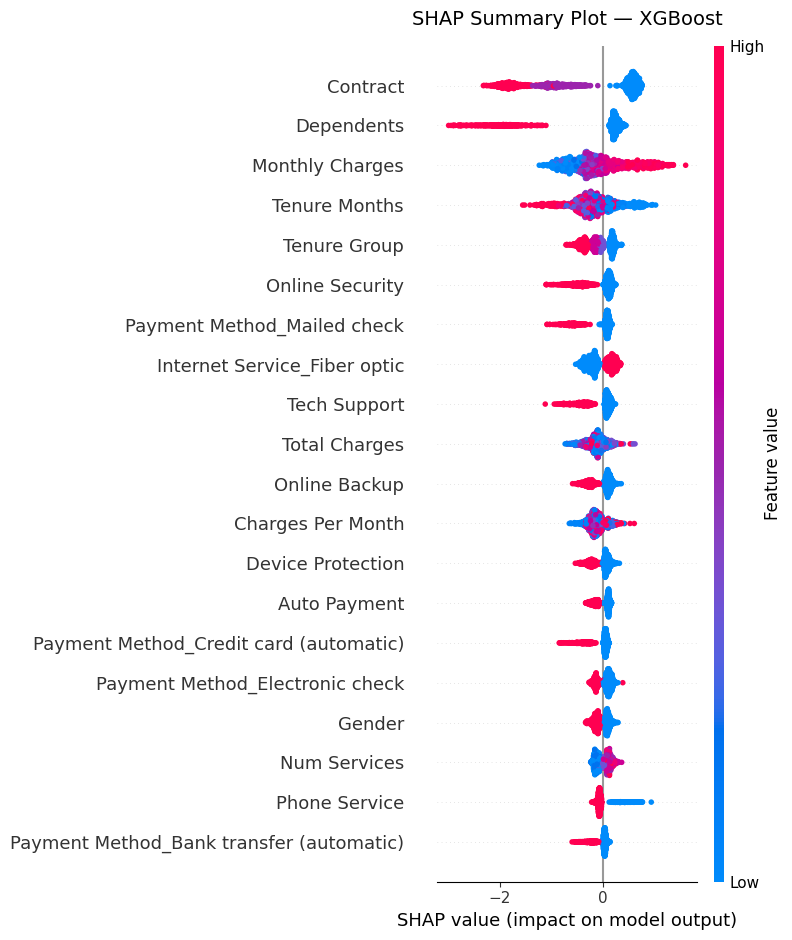

✅ Saved: shap_summary_beeswarm.png


In [3]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, show=False, max_display=20)
plt.title('SHAP Summary Plot — XGBoost', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'shap_summary_beeswarm.png', bbox_inches='tight')
plt.show()
print('✅ Saved: shap_summary_beeswarm.png')

## 4. SHAP Bar Plot

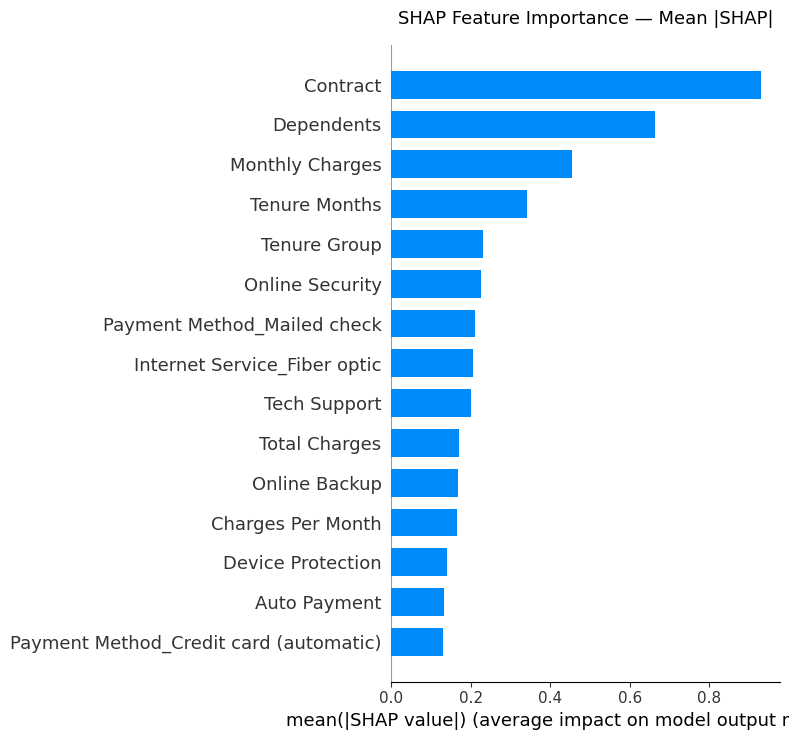

In [4]:
plt.figure(figsize=(9, 7))
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False, max_display=15)
plt.title('SHAP Feature Importance — Mean |SHAP|', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'shap_bar_importance.png', bbox_inches='tight')
plt.show()

## 5. Waterfall — Churned Customer

Customer index: 1 | Actual: Churned
Predicted prob: 0.4411


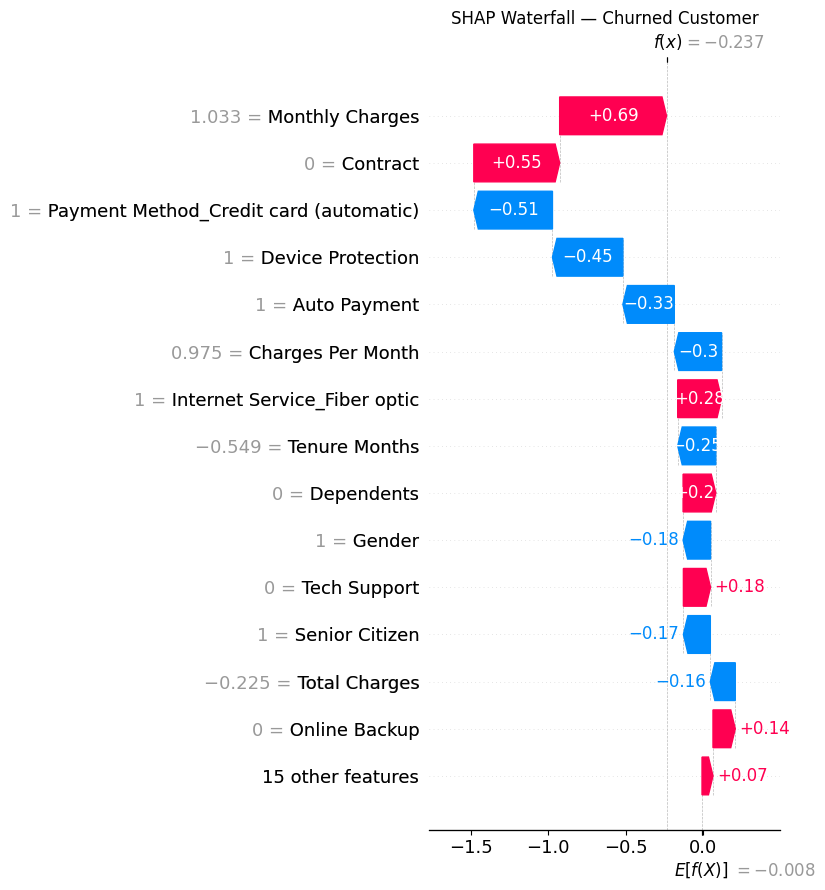

In [5]:
churned_idx = np.where(y_test.values == 1)[0][0]
print(f'Customer index: {churned_idx} | Actual: Churned')
print(f'Predicted prob: {best_model.predict_proba(X_test)[churned_idx, 1]:.4f}')

explanation = shap.Explanation(
    values=shap_values[churned_idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[churned_idx],
    feature_names=X_test.columns.tolist()
)
plt.figure(figsize=(10, 6))
shap.waterfall_plot(explanation, show=False, max_display=15)
plt.title('SHAP Waterfall — Churned Customer')
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'shap_waterfall_churned.png', bbox_inches='tight')
plt.show()

## 6. Waterfall — Retained Customer

Customer index: 0 | Actual: Retained
Predicted prob: 0.8867


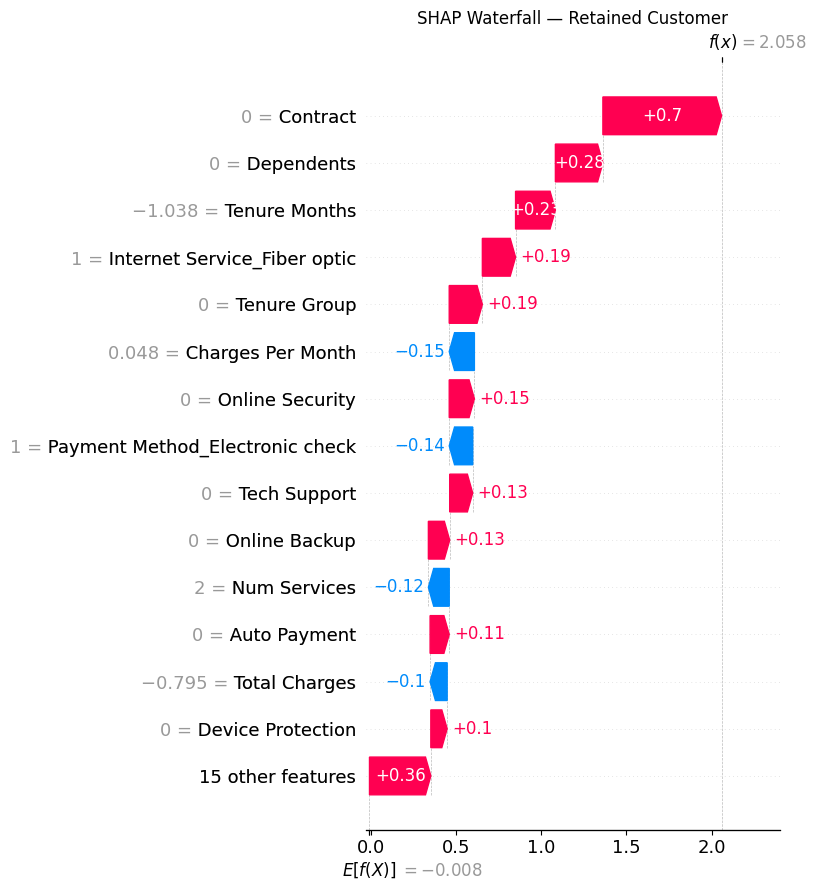

In [6]:
retained_idx = np.where(y_test.values == 0)[0][0]
print(f'Customer index: {retained_idx} | Actual: Retained')
print(f'Predicted prob: {best_model.predict_proba(X_test)[retained_idx, 1]:.4f}')

explanation2 = shap.Explanation(
    values=shap_values[retained_idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[retained_idx],
    feature_names=X_test.columns.tolist()
)
plt.figure(figsize=(10, 6))
shap.waterfall_plot(explanation2, show=False, max_display=15)
plt.title('SHAP Waterfall — Retained Customer')
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'shap_waterfall_retained.png', bbox_inches='tight')
plt.show()

## 7. Dependence Plots — Key Features

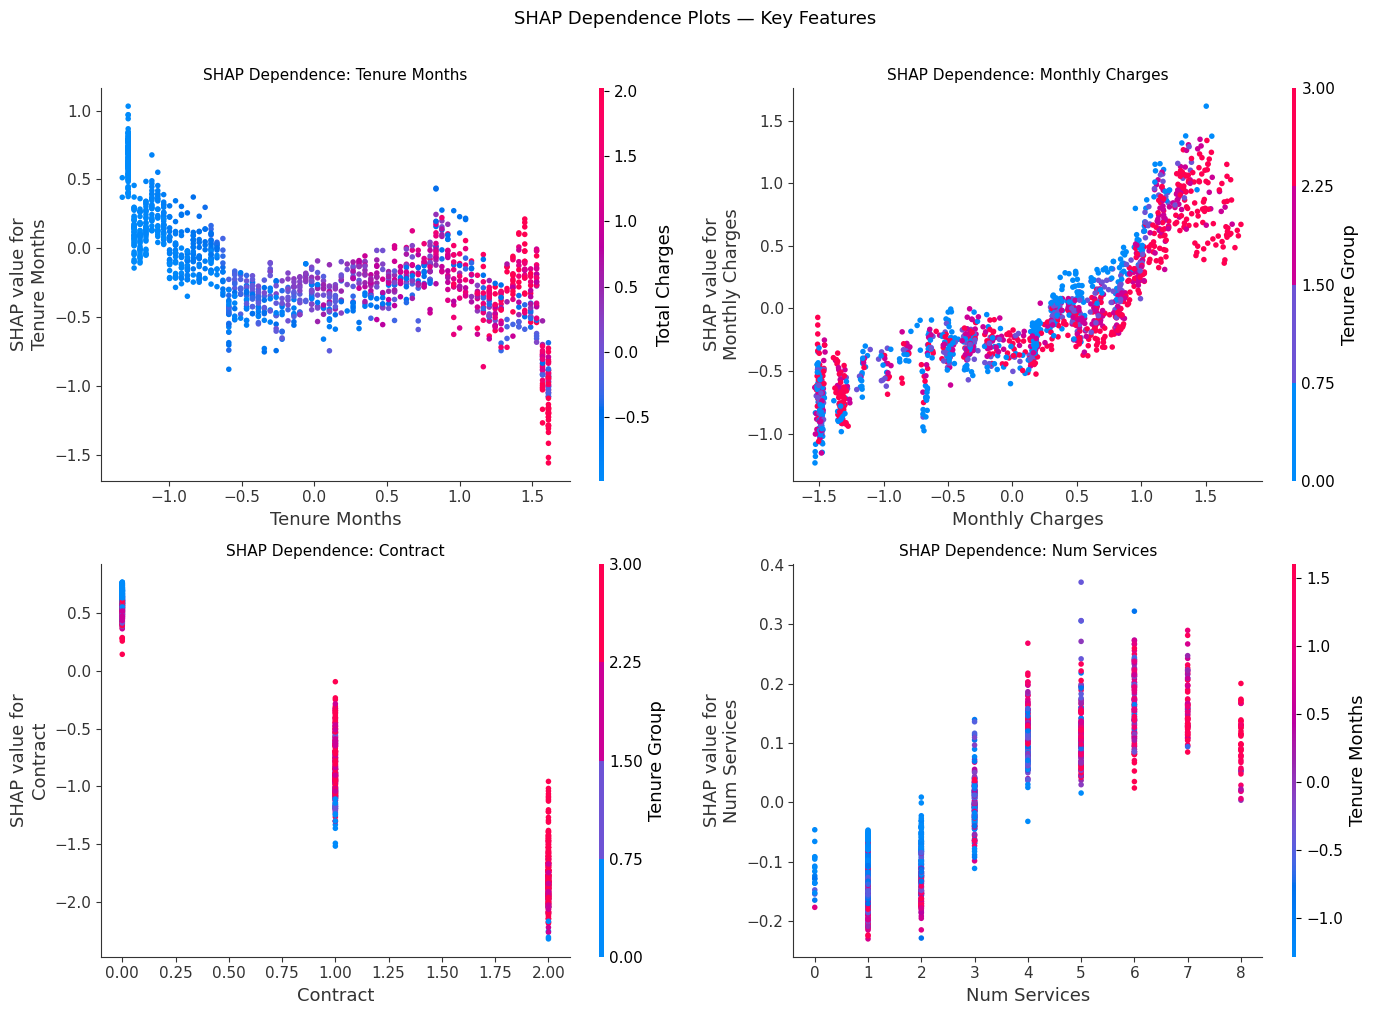

In [7]:
key_features = ['Tenure Months', 'Monthly Charges', 'Contract', 'Num Services']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, feat in enumerate(key_features):
    shap.dependence_plot(feat, shap_values, X_test, ax=axes[i], show=False)
    axes[i].set_title(f'SHAP Dependence: {feat}', fontsize=11)
plt.suptitle('SHAP Dependence Plots — Key Features', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'shap_dependence_plots.png', bbox_inches='tight')
plt.show()

## 8. High-Risk Customer Identification

In [8]:
churn_prob = best_model.predict_proba(X_test)[:, 1]
risk_df = X_test.copy()
risk_df['Churn Probability'] = churn_prob.round(4)
risk_df['SHAP Magnitude']    = np.abs(shap_values).mean(axis=1).round(4)
risk_df['Actual Churn']      = y_test.values
risk_df['Risk Tier'] = pd.cut(
    risk_df['Churn Probability'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low', 'Medium', 'High']
)
print('Risk Tier Distribution:')
print(risk_df['Risk Tier'].value_counts())
print('\nTop 10 Highest Risk Customers:')
display(
    risk_df.sort_values('Churn Probability', ascending=False)
    [['Tenure Months','Monthly Charges','Contract','Num Services',
      'Churn Probability','Risk Tier','Actual Churn']].head(10)
)

Risk Tier Distribution:
Risk Tier
Low       788
High      382
Medium    235
Name: count, dtype: int64

Top 10 Highest Risk Customers:


,Tenure Months,Monthly Charges,Contract,Num Services,Churn Probability,Risk Tier,Actual Churn
1641,-1.119684,1.185628,0,5,0.9724,High,1
638,-1.282728,0.409025,0,2,0.9719,High,1
581,-1.282728,1.195606,0,5,0.9715,High,1
923,-1.282728,0.490510,0,2,0.9693,High,1
1240,-1.282728,0.468892,0,2,0.9690,High,1
1073,-1.282728,0.438959,0,2,0.9666,High,1
370,-1.282728,0.370777,0,2,0.9612,High,1
1029,-1.078923,0.954476,0,4,0.9611,High,1
1070,-1.282728,0.157918,0,1,0.9607,High,1
1449,-1.282728,0.540399,0,2,0.9605,High,1


## 9. Save All Artifacts

In [ ]:
os.makedirs('../reports', exist_ok=True)

pd.DataFrame(shap_values, columns=X_test.columns).to_csv('../reports/shap_values.csv', index=False)
risk_df.to_csv('../reports/customer_risk_scores.csv', index=False)
joblib.dump(explainer, '../models/shap_explainer.pkl')

print('✅ reports/shap_values.csv')
print('✅ reports/customer_risk_scores.csv')
print('✅ models/shap_explainer.pkl')


✅ reports/shap_values.csv
✅ reports/customer_risk_scores.csv
✅ models/shap_explainer.pkl

→ Ready for Streamlit Dashboard!
